Libraries loaded successfully
Feature cols       : 21
Test set           : (384, 21)
High-DSR cases     : 60  (DSR >= 0.4)
Mean actual DSR    : 1.8113
Policy scenarios defined:
  Policy A-20 (Debt -20%): {'debt_financial': -0.2}
  Policy A-40 (Debt -40%): {'debt_financial': -0.4}
  Policy A-60 (Debt -60%): {'debt_financial': -0.6}
  Policy B-20 (Income +20%): {'h19_pers_income2': 0.2}
  Policy B-40 (Income +40%): {'h19_pers_income2': 0.4}
  Policy B-60 (Income +60%): {'h19_pers_income2': 0.6}
  Policy C (A-40+B-40): {'debt_financial': -0.4, 'h19_pers_income2': 0.4}
Baseline mean predicted DSR  : 1.2906
Baseline crisis proxy rate   : 71.7%  (pred DSR >= 0.4)
Policy A-20 (Debt -20%)      | mean DSR: 1.2125 | DSR drop: 0.0781 | crisis rate: 68.3% | rescued: 2
Policy A-40 (Debt -40%)      | mean DSR: 1.1156 | DSR drop: 0.1749 | crisis rate: 63.3% | rescued: 5
Policy A-60 (Debt -60%)      | mean DSR: 1.0027 | DSR drop: 0.2879 | crisis rate: 60.0% | rescued: 7
Policy B-20 (Income +20%)    | 

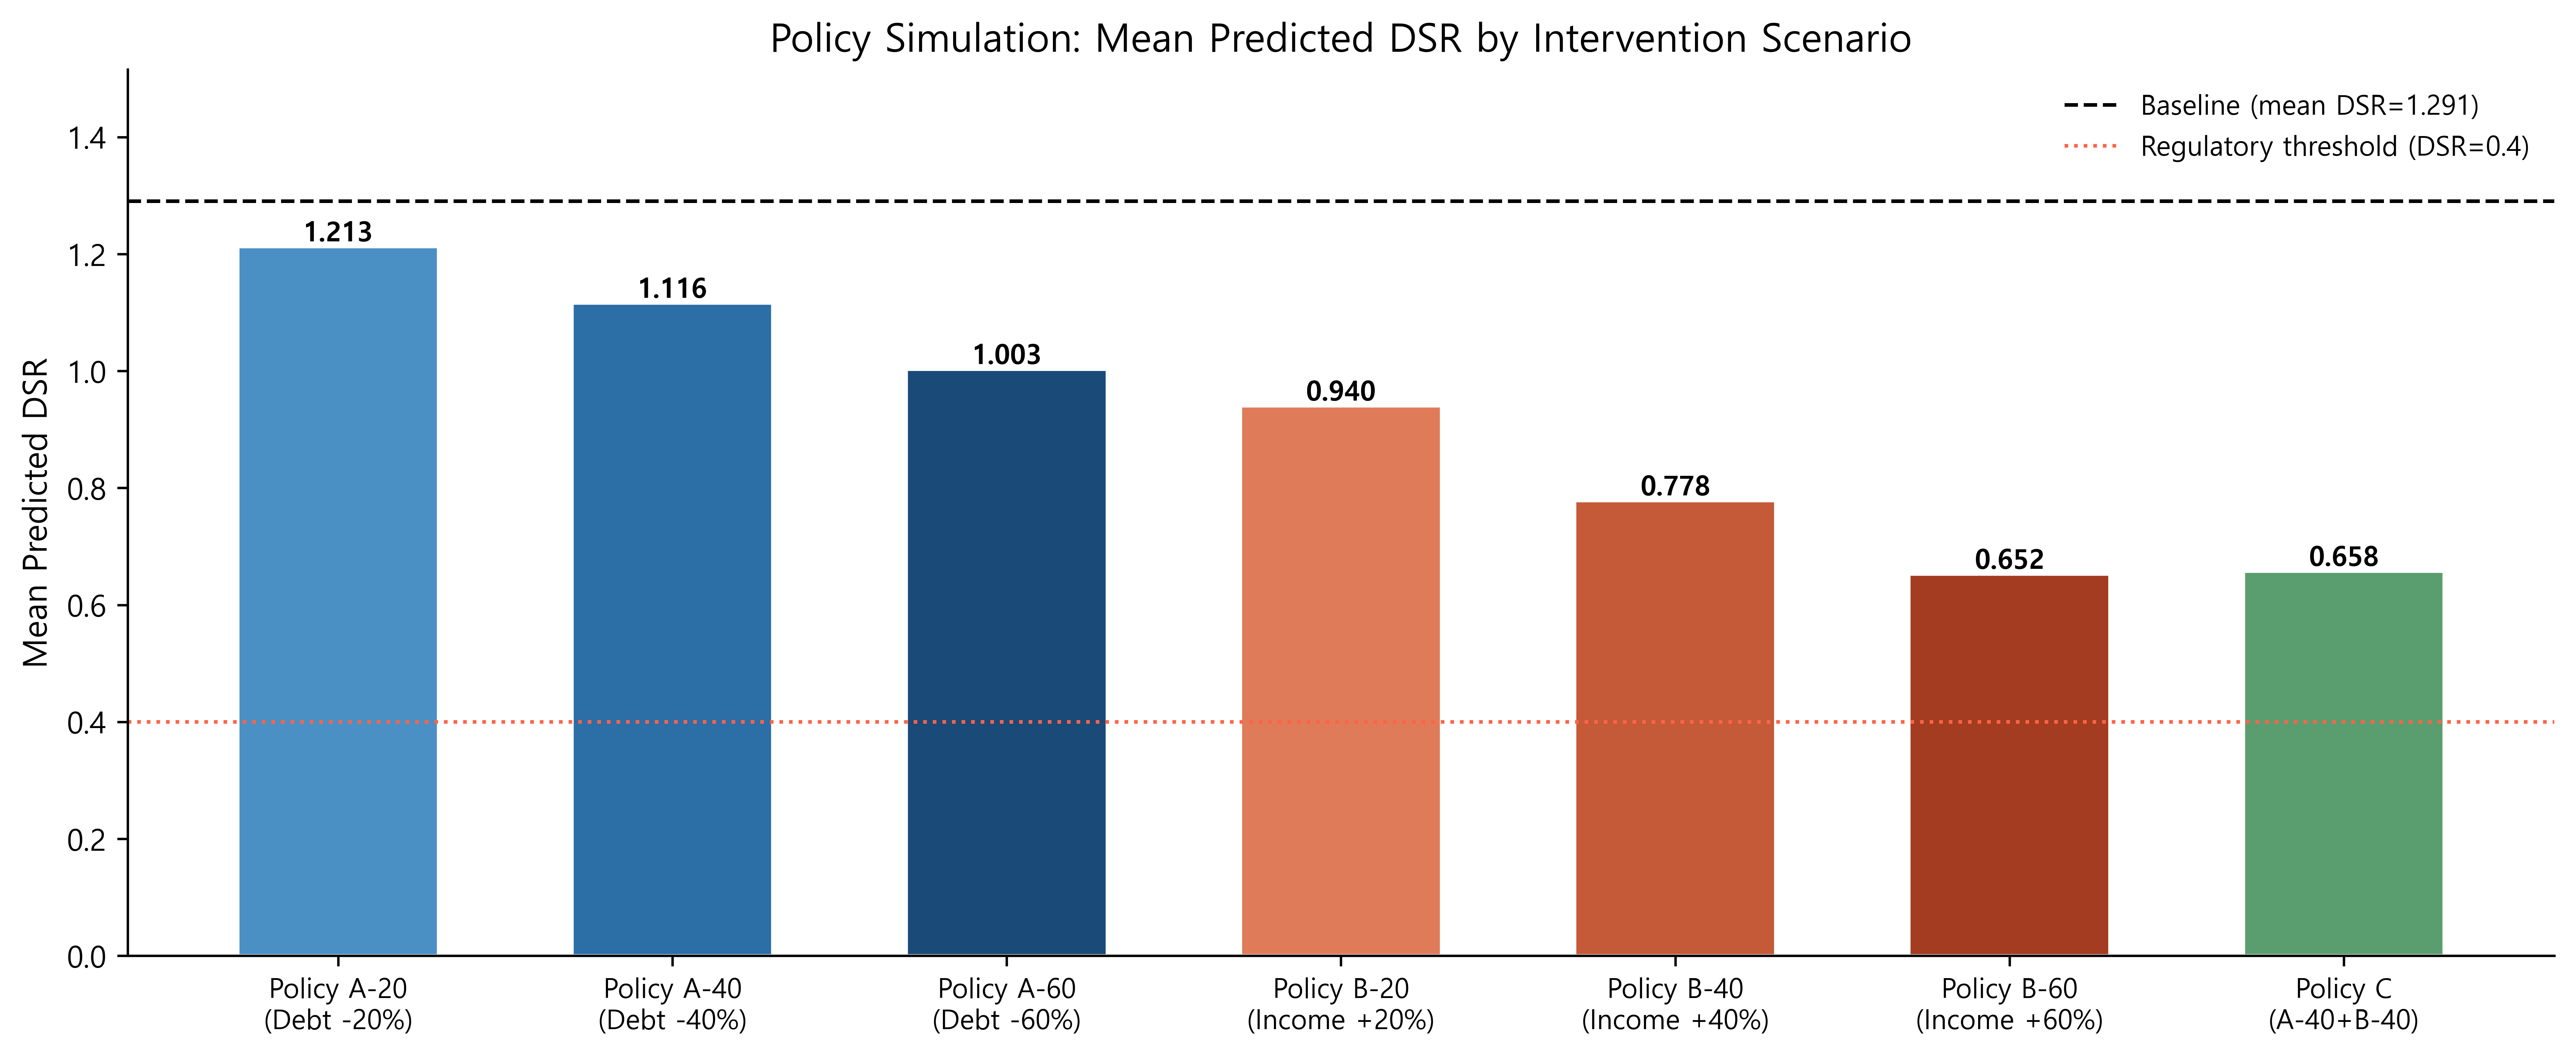

Saved -> outputs/24_policy_mean_dsr.png


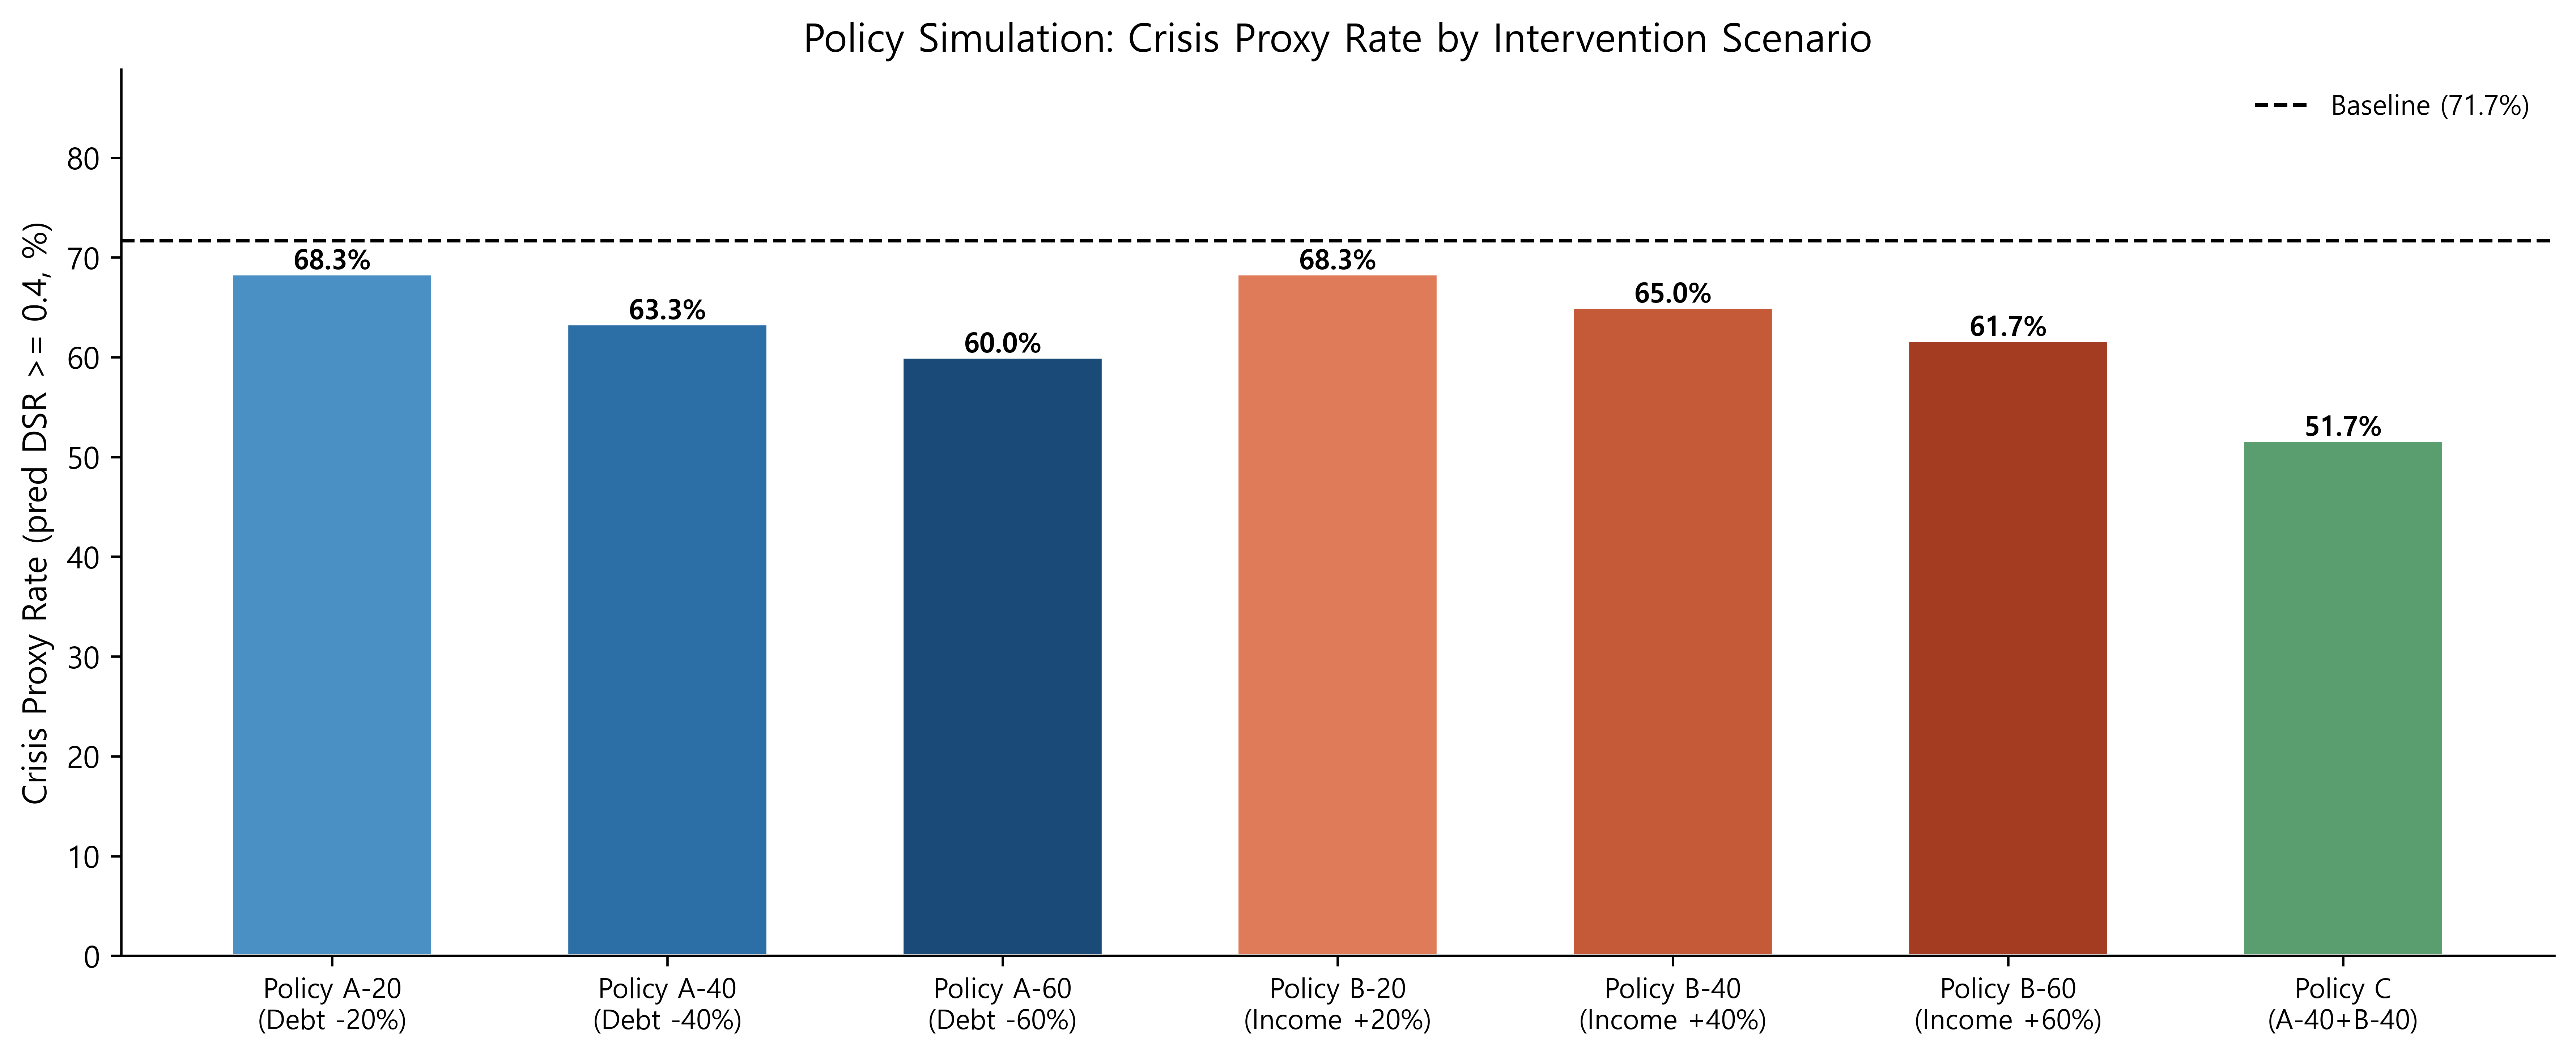

Saved -> outputs/25_policy_crisis_rate_reg.png


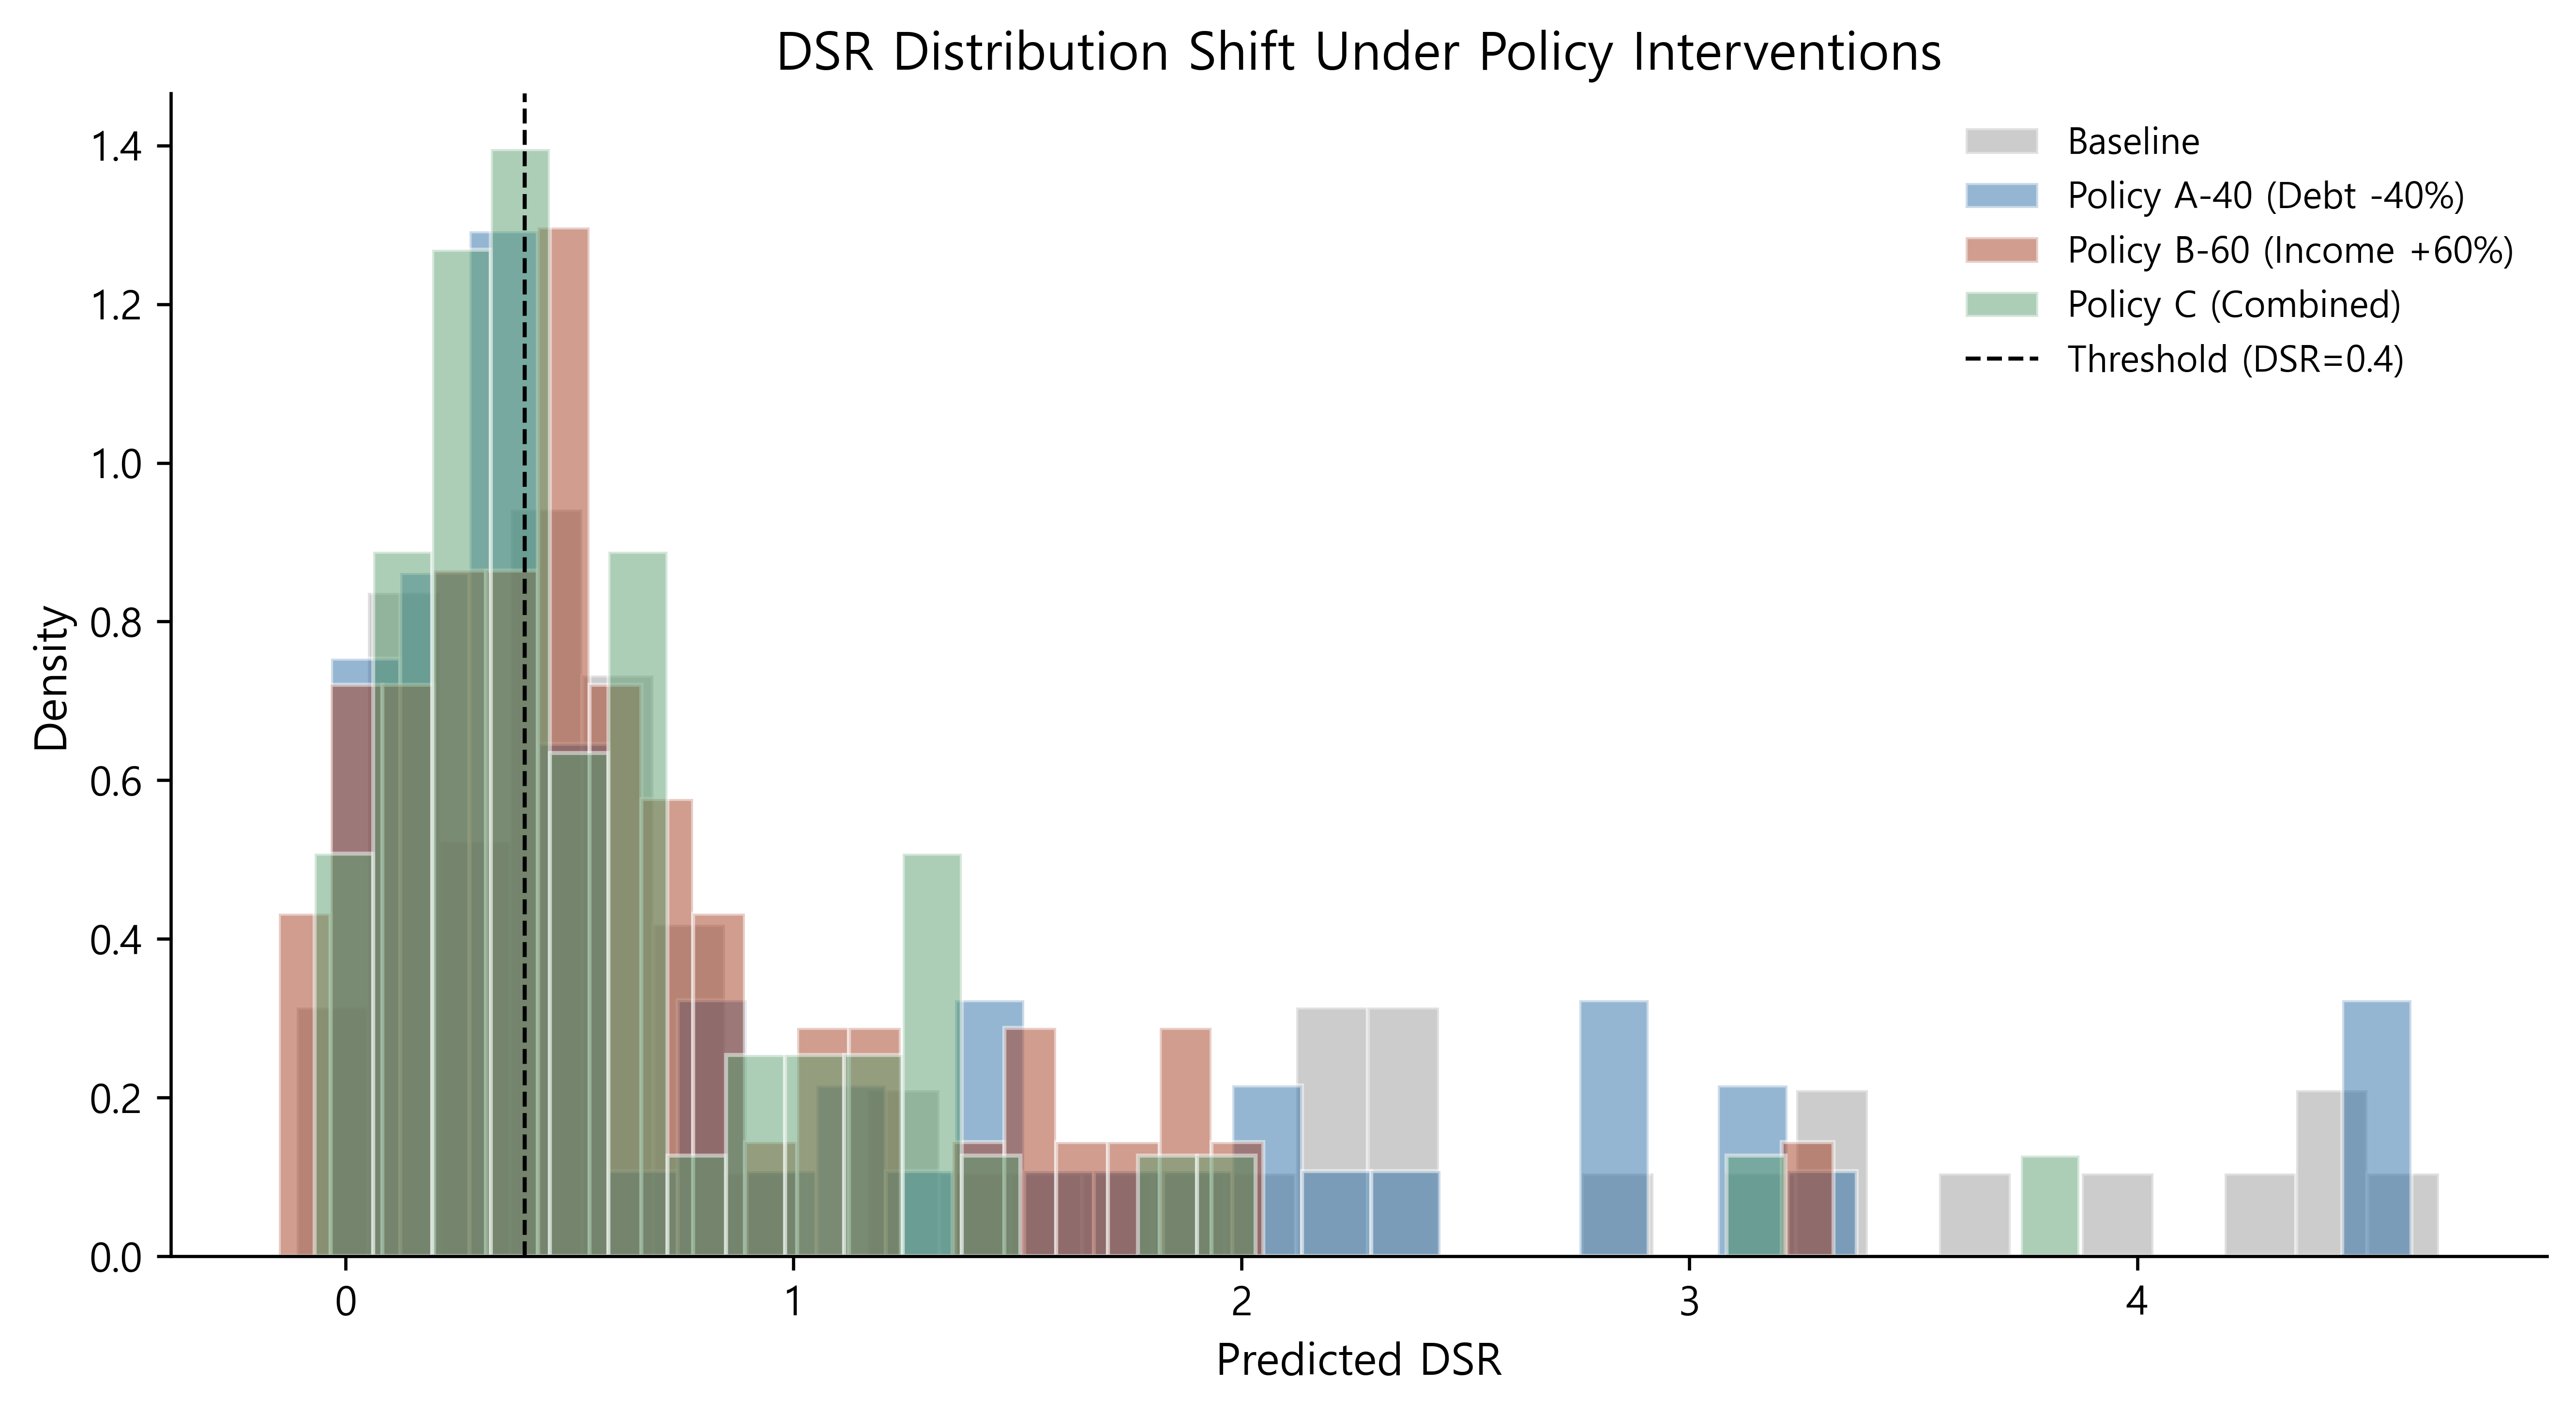

Saved -> outputs/26_policy_dsr_shift_reg.png
=== Policy C effect by employment status (Heterogeneity) ===
  Subgroup  N  Baseline mean DSR  Post-policy mean DSR  DSR reduction Baseline crisis rate Post-policy crisis rate
  Employed 15             0.3813                0.3699         0.0114                53.3%                   46.7%
Unemployed 13             0.5023                0.3403         0.1620                46.2%                    7.7%
  Inactive  2             2.1875                0.9558         1.2317               100.0%                  100.0%
Saved -> outputs/policy_heterogeneity_reg.csv


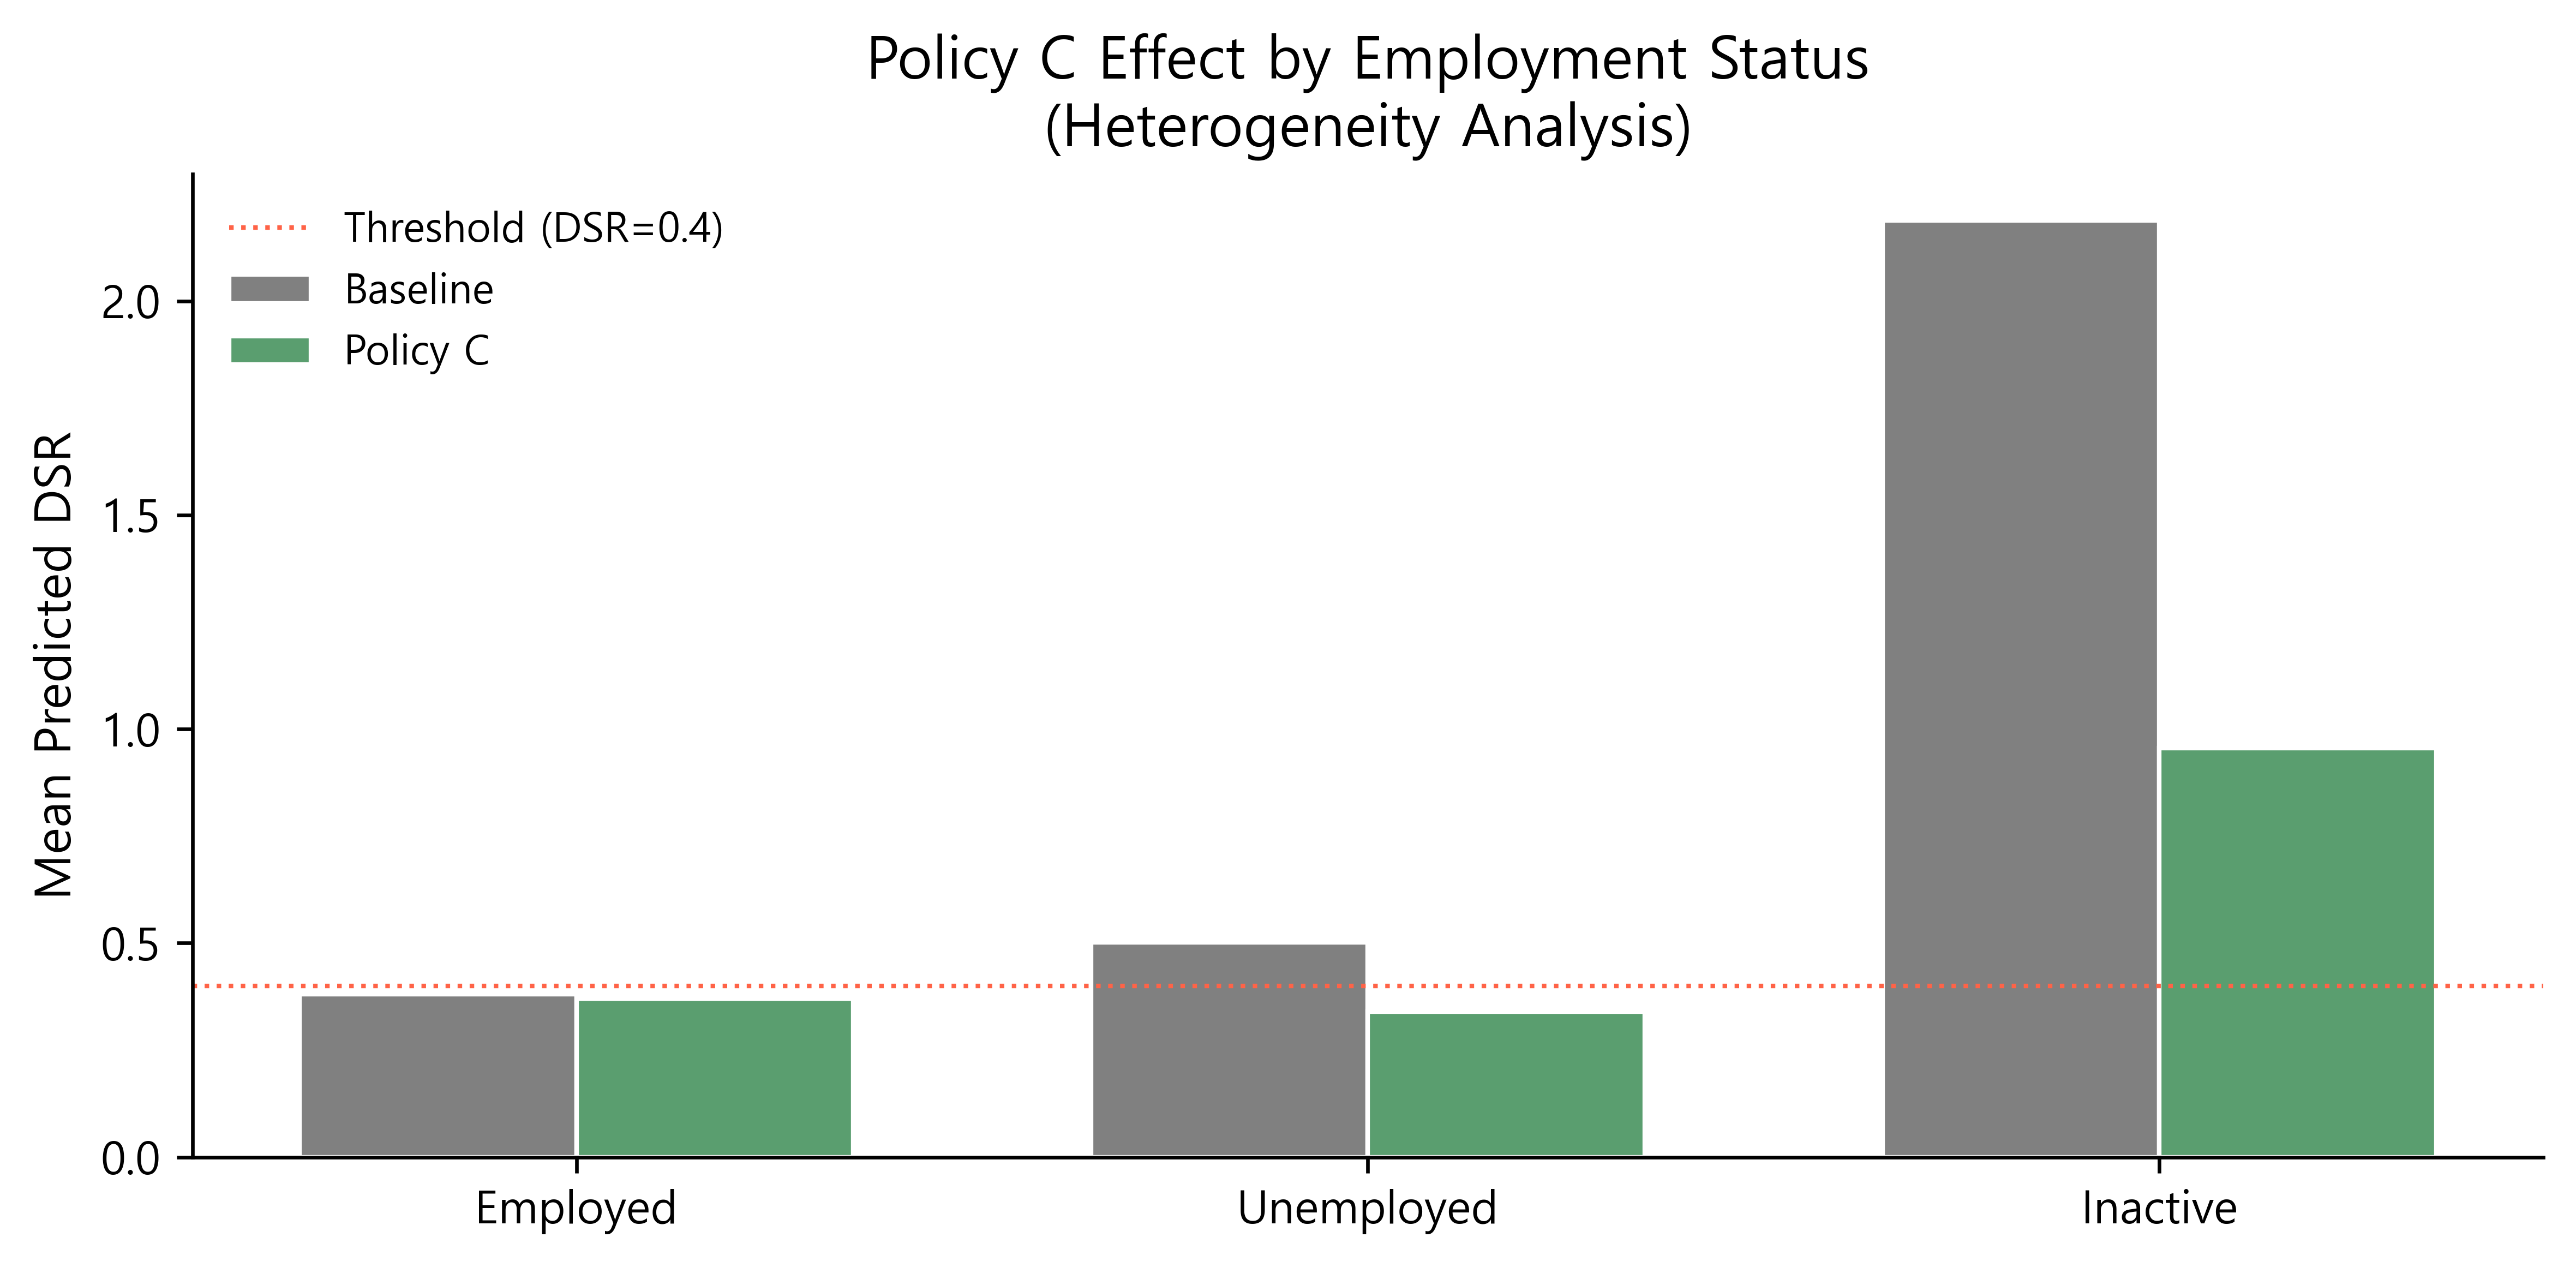

Saved -> outputs/27_policy_heterogeneity_reg.png


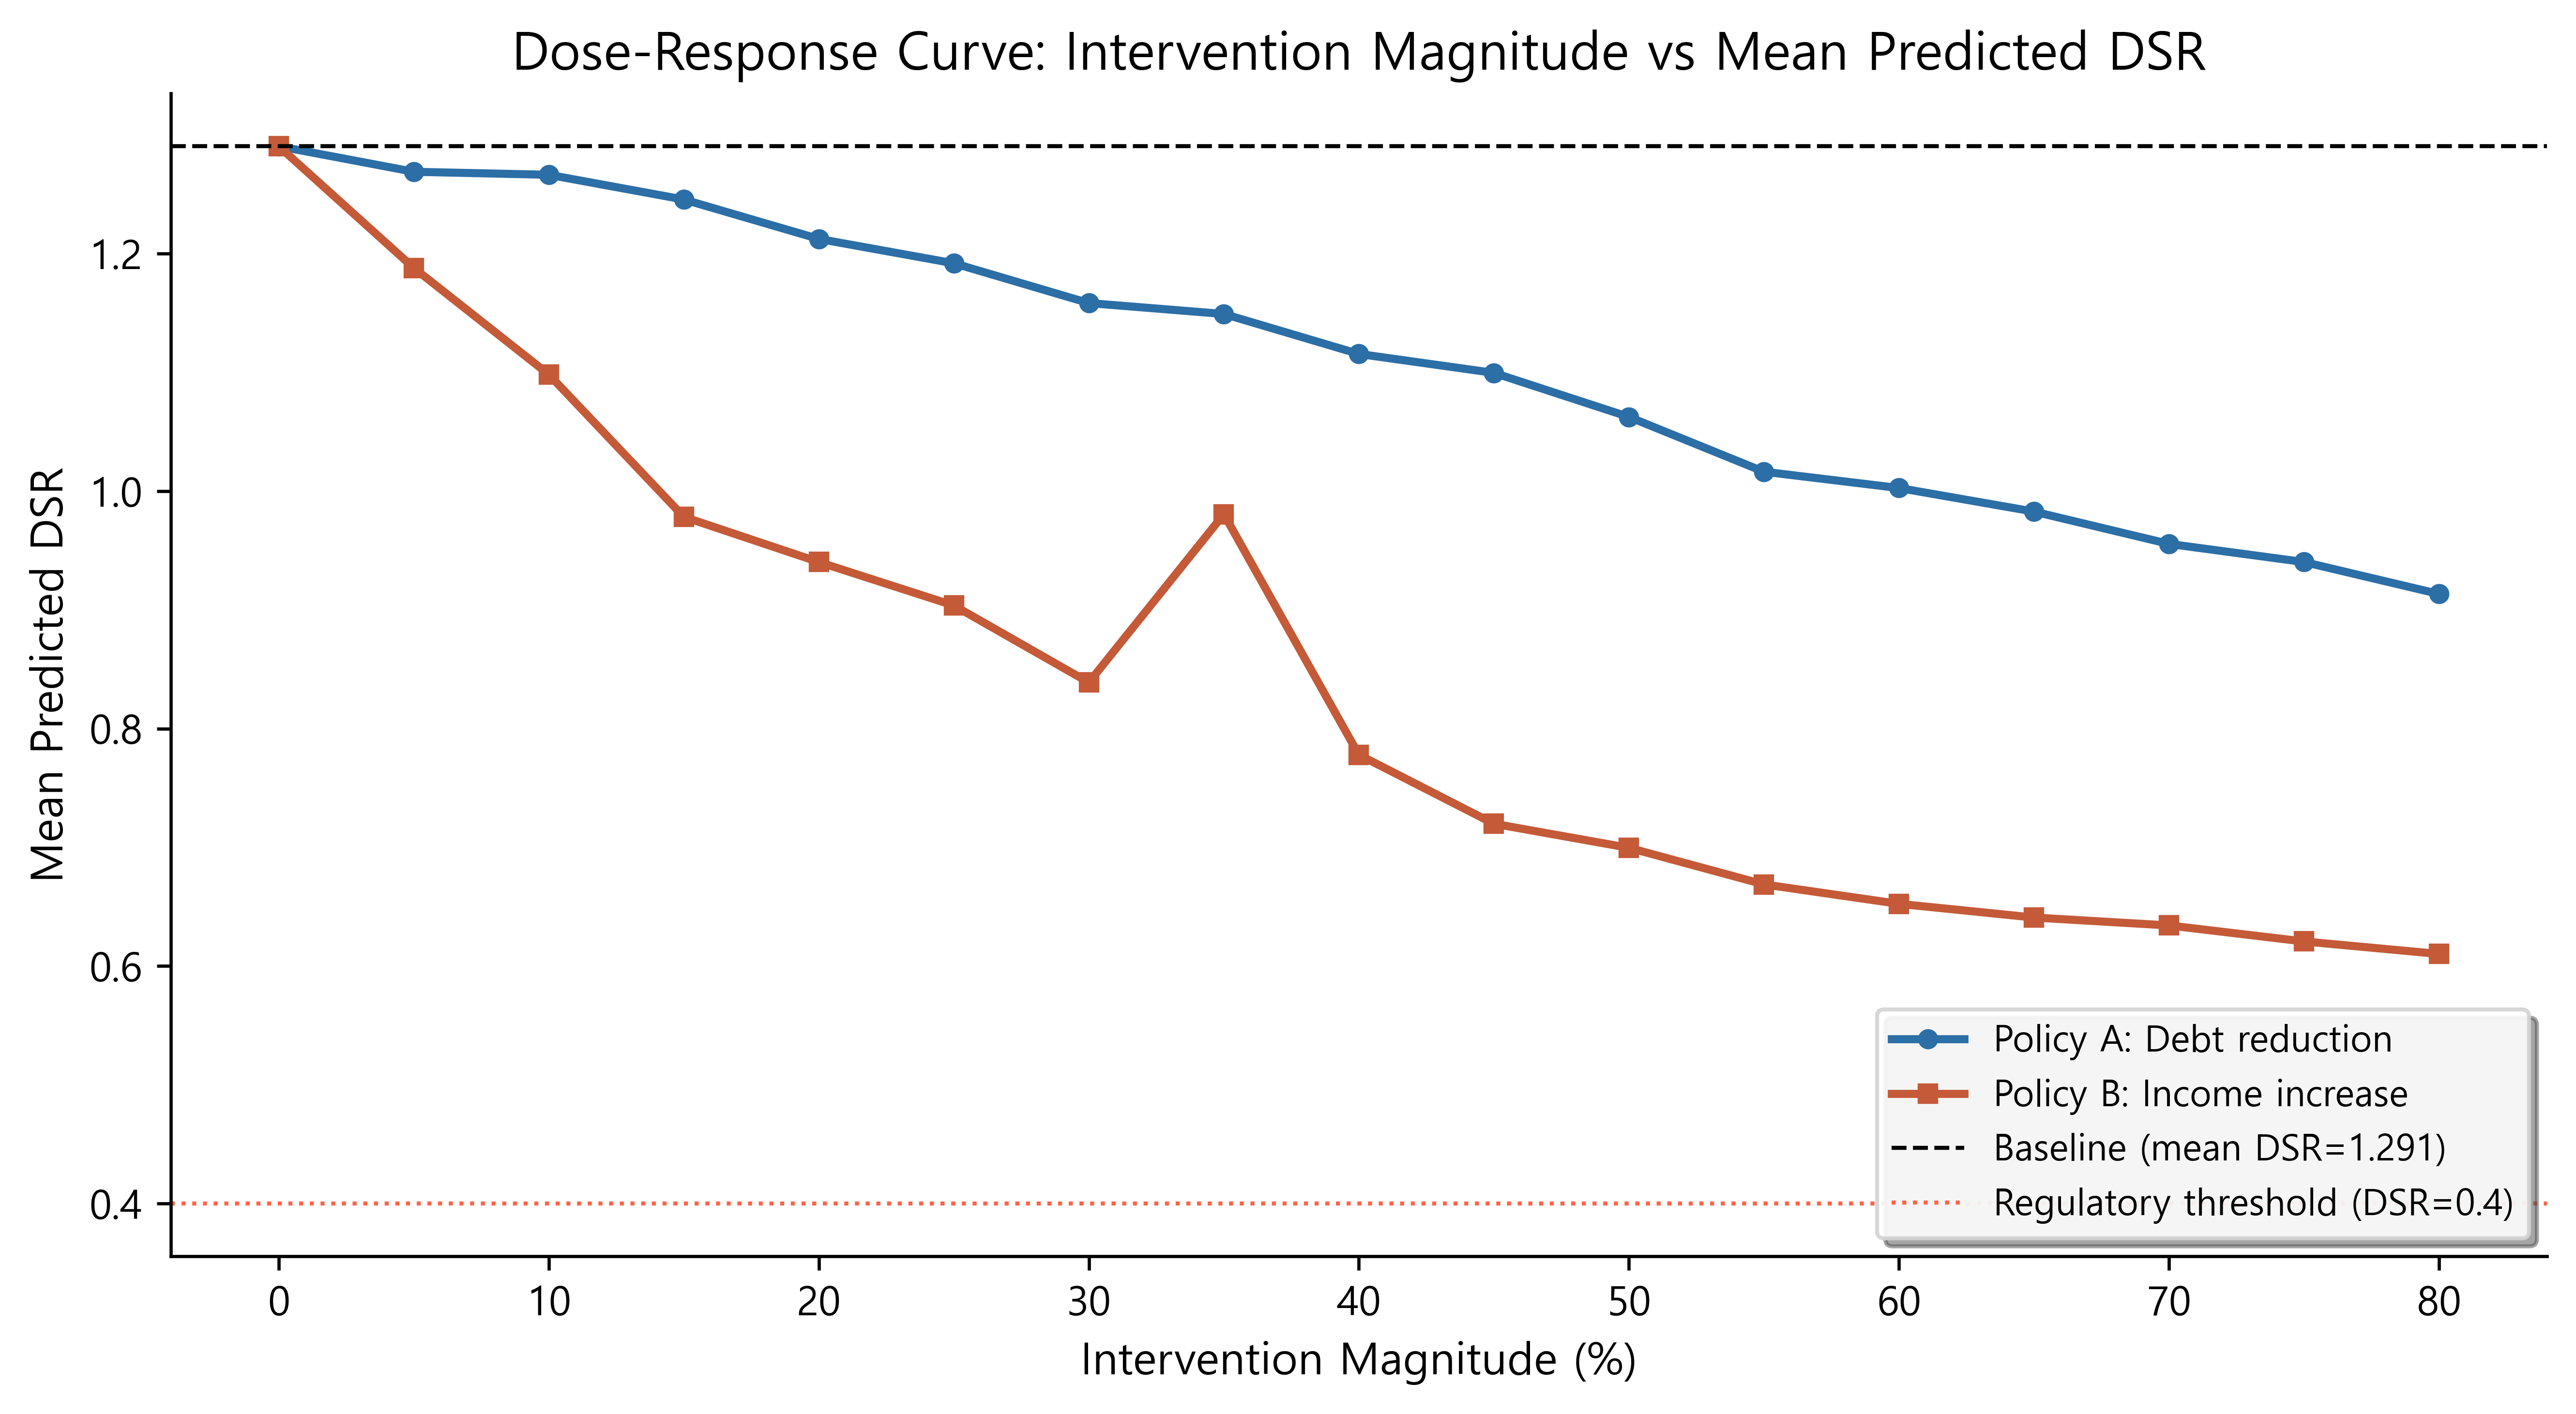

Saved -> outputs/28_dose_response_reg.png
Saved -> outputs/dose_response_reg.csv

All policy simulation outputs saved to outputs/


In [4]:
# ═══════════════════════════════════════════════════════════════
# Notebook  : 06_policy_simulation_regression
# Project   : XAI-Driven DSR Prediction Framework for Youth Debt Crisis
# Purpose   : Policy simulation using regression model predictions
#             Outcome: mean predicted DSR + DSR >= 0.4 rate (crisis proxy)
#             Scenarios: debt reduction (A), income support (B), combined (C)
#             Heterogeneity analysis by employment status subgroup
# Data      : X_test_reg.csv, y_test_reg.csv, model_lgbm_reg.pkl
# Author    :
# ═══════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────
# Cell 1 | Import libraries
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
import joblib

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 600
matplotlib.rcParams['savefig.dpi'] = 600
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['axes.titlesize'] = 13
matplotlib.rcParams['axes.labelsize'] = 11
matplotlib.rcParams['xtick.labelsize'] = 10
matplotlib.rcParams['ytick.labelsize'] = 10
matplotlib.rcParams['lines.linewidth'] = 1.5
matplotlib.rcParams['axes.linewidth'] = 0.8

SAVE_KW = dict(dpi=600, bbox_inches='tight', format='png')

print("Libraries loaded successfully")


# ─────────────────────────────────────────────
# Cell 2 | Load model & data
# ─────────────────────────────────────────────
lgbm    = joblib.load('../outputs/model_lgbm_reg.pkl')
X_test  = pd.read_csv('../data/X_test_reg.csv')
y_test  = pd.read_csv('../data/y_test_reg.csv').squeeze()
imputer = joblib.load('../outputs/imputer_reg.pkl')

FEATURE_COLS = pd.read_csv('../data/feature_cols_reg.csv').iloc[:, 0].tolist()

X_test_r = X_test.reset_index(drop=True)
y_test_r = y_test.reset_index(drop=True)

# High-DSR cases only (regulatory threshold: DSR >= 0.4)
DSR_THRESHOLD = 0.4
crisis_mask   = y_test_r >= DSR_THRESHOLD
X_crisis      = X_test_r[crisis_mask].copy().reset_index(drop=True)
y_crisis      = y_test_r[crisis_mask].copy().reset_index(drop=True)

print(f"Feature cols       : {len(FEATURE_COLS)}")
print(f"Test set           : {X_test_r.shape}")
print(f"High-DSR cases     : {X_crisis.shape[0]}  (DSR >= {DSR_THRESHOLD})")
print(f"Mean actual DSR    : {y_crisis.mean():.4f}")


# ─────────────────────────────────────────────
# Cell 3 | Define policy scenarios
# Based on SHAP and DiCE findings:
#   - debt_financial (top SHAP feature) -> debt relief policy
#   - h19_pers_income2 (2nd SHAP feature) -> income stabilisation policy
# ─────────────────────────────────────────────
POLICIES = {
    'Policy A-20\n(Debt -20%)'  : {'debt_financial'  : -0.20},
    'Policy A-40\n(Debt -40%)'  : {'debt_financial'  : -0.40},
    'Policy A-60\n(Debt -60%)'  : {'debt_financial'  : -0.60},
    'Policy B-20\n(Income +20%)': {'h19_pers_income2': +0.20},
    'Policy B-40\n(Income +40%)': {'h19_pers_income2': +0.40},
    'Policy B-60\n(Income +60%)': {'h19_pers_income2': +0.60},
    'Policy C\n(A-40+B-40)'     : {'debt_financial'  : -0.40,
                                    'h19_pers_income2': +0.40},
}

print("Policy scenarios defined:")
for k, v in POLICIES.items():
    print(f"  {k.replace(chr(10), ' ')}: {v}")


# ─────────────────────────────────────────────
# Cell 4 | Simulate policy effects
# Outcome 1: mean predicted DSR (lower = better)
# Outcome 2: proportion with predicted DSR >= 0.4 (crisis proxy rate)
# ─────────────────────────────────────────────
baseline_preds      = lgbm.predict(X_crisis.values)
baseline_mean_dsr   = baseline_preds.mean()
baseline_crisis_rate = (baseline_preds >= DSR_THRESHOLD).mean()

print(f"Baseline mean predicted DSR  : {baseline_mean_dsr:.4f}")
print(f"Baseline crisis proxy rate   : {baseline_crisis_rate:.1%}  (pred DSR >= {DSR_THRESHOLD})")

sim_results = {}

for policy_name, changes in POLICIES.items():
    X_sim = X_crisis.copy()

    for feat, delta in changes.items():
        if feat not in X_sim.columns:
            continue
        if delta < 0:
            # Debt reduction: multiply by (1 + delta), floor at 0
            X_sim[feat] = (X_sim[feat] * (1 + delta)).clip(lower=0)
        else:
            # Income increase: add delta * column mean of crisis group
            col_mean    = X_crisis[feat].mean()
            X_sim[feat] = X_sim[feat] + col_mean * delta

    sim_preds      = lgbm.predict(X_sim.values)
    sim_mean_dsr   = sim_preds.mean()
    sim_crisis_rate = (sim_preds >= DSR_THRESHOLD).mean()
    dsr_reduction  = baseline_mean_dsr - sim_mean_dsr
    rate_reduction = baseline_crisis_rate - sim_crisis_rate
    n_rescued      = int((baseline_preds >= DSR_THRESHOLD).sum() -
                         (sim_preds >= DSR_THRESHOLD).sum())

    sim_results[policy_name] = {
        'mean_dsr'      : sim_mean_dsr,
        'crisis_rate'   : sim_crisis_rate,
        'dsr_reduction' : dsr_reduction,
        'rate_reduction': rate_reduction,
        'n_rescued'     : n_rescued,
        'preds'         : sim_preds,
    }

    label = policy_name.replace('\n', ' ')
    print(f"{label:<28} | mean DSR: {sim_mean_dsr:.4f} "
          f"| DSR drop: {dsr_reduction:.4f} "
          f"| crisis rate: {sim_crisis_rate:.1%} "
          f"| rescued: {n_rescued}")


# ─────────────────────────────────────────────
# Cell 5 | Policy effect summary table
# ─────────────────────────────────────────────
rows = []
for name, res in sim_results.items():
    rows.append({
        'Policy'          : name.replace('\n', ' '),
        'Mean pred DSR'   : round(res['mean_dsr'], 4),
        'DSR reduction'   : round(res['dsr_reduction'], 4),
        'Crisis proxy rate': f"{res['crisis_rate']:.1%}",
        'Rate reduction'  : f"{res['rate_reduction']:.1%}",
        'Cases rescued'   : res['n_rescued'],
    })

summary_tbl = pd.DataFrame(rows)
print(f"\n=== Policy Simulation Summary (Baseline mean DSR = {baseline_mean_dsr:.4f}) ===")
print(summary_tbl.to_string(index=False))

summary_tbl.to_csv('../outputs/policy_simulation_summary_reg.csv',
                   index=False, encoding='utf-8-sig')
print("\nSaved -> outputs/policy_simulation_summary_reg.csv")


# ─────────────────────────────────────────────
# Cell 6 | Bar chart — mean predicted DSR by policy
# ─────────────────────────────────────────────
policy_names = [k.replace('\n', '\n') for k in sim_results.keys()]
mean_dsrs    = [v['mean_dsr'] for v in sim_results.values()]
colors       = ['#4a90c4', '#2c6ea6', '#1a4a78',
                '#e07b5a', '#c45a38', '#a33c20',
                '#5a9e6f']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(policy_names)), mean_dsrs,
              color=colors, edgecolor='white', width=0.6)

ax.axhline(baseline_mean_dsr, color='black', linestyle='--',
           lw=1.2, label=f'Baseline (mean DSR={baseline_mean_dsr:.3f})')
ax.axhline(DSR_THRESHOLD, color='tomato', linestyle=':',
           lw=1.2, label=f'Regulatory threshold (DSR={DSR_THRESHOLD})')

for bar, val in zip(bars, mean_dsrs):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 0.01, f'{val:.3f}',
            ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(range(len(policy_names)))
ax.set_xticklabels(policy_names, fontsize=9)
ax.set_ylabel('Mean Predicted DSR')
ax.set_title('Policy Simulation: Mean Predicted DSR by Intervention Scenario')
ax.legend(frameon=False, fontsize=9)
ax.set_ylim(0, max(mean_dsrs) * 1.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/24_policy_mean_dsr.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/24_policy_mean_dsr.png")


# ─────────────────────────────────────────────
# Cell 7 | Bar chart — crisis proxy rate by policy
# ─────────────────────────────────────────────
crisis_rates = [v['crisis_rate'] * 100 for v in sim_results.values()]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(policy_names)), crisis_rates,
              color=colors, edgecolor='white', width=0.6)

ax.axhline(baseline_crisis_rate * 100, color='black', linestyle='--',
           lw=1.2, label=f'Baseline ({baseline_crisis_rate:.1%})')

for bar, val in zip(bars, crisis_rates):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 0.5, f'{val:.1f}%',
            ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(range(len(policy_names)))
ax.set_xticklabels(policy_names, fontsize=9)
ax.set_ylabel('Crisis Proxy Rate (pred DSR >= 0.4, %)')
ax.set_title('Policy Simulation: Crisis Proxy Rate by Intervention Scenario')
ax.legend(frameon=False, fontsize=9)
ax.set_ylim(0, max(crisis_rates) * 1.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/25_policy_crisis_rate_reg.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/25_policy_crisis_rate_reg.png")


# ─────────────────────────────────────────────
# Cell 8 | DSR distribution shift under key policies
# ─────────────────────────────────────────────
key_policies = [
    ('Policy A-40\n(Debt -40%)',   '#2c6ea6', 'Policy A-40 (Debt -40%)'),
    ('Policy B-60\n(Income +60%)', '#a33c20', 'Policy B-60 (Income +60%)'),
    ('Policy C\n(A-40+B-40)',      '#5a9e6f', 'Policy C (Combined)'),
]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(baseline_preds, bins=30, alpha=0.4, color='gray',
        label='Baseline', edgecolor='white', density=True)

for key, color, label in key_policies:
    if key in sim_results:
        ax.hist(sim_results[key]['preds'], bins=30, alpha=0.5,
                color=color, label=label,
                edgecolor='white', density=True)

ax.axvline(DSR_THRESHOLD, color='black', linestyle='--',
           lw=1.0, label=f'Threshold (DSR={DSR_THRESHOLD})')
ax.set_xlabel('Predicted DSR')
ax.set_ylabel('Density')
ax.set_title('DSR Distribution Shift Under Policy Interventions')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/26_policy_dsr_shift_reg.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/26_policy_dsr_shift_reg.png")


# ─────────────────────────────────────────────
# Cell 9 | Heterogeneity analysis by employment status
# ─────────────────────────────────────────────
emp_labels = {1: 'Employed', 2: 'Unemployed', 3: 'Inactive'}
policy_key = 'Policy C\n(A-40+B-40)'

if policy_key in sim_results and 'employment_status' in X_crisis.columns:
    subgroup_rows = []

    for emp_val, emp_label in emp_labels.items():
        mask = (X_crisis['employment_status'] == emp_val)
        if mask.sum() == 0:
            continue

        base_p = baseline_preds[mask.values]
        sim_p  = sim_results[policy_key]['preds'][mask.values]

        subgroup_rows.append({
            'Subgroup'              : emp_label,
            'N'                     : int(mask.sum()),
            'Baseline mean DSR'     : round(base_p.mean(), 4),
            'Post-policy mean DSR'  : round(sim_p.mean(), 4),
            'DSR reduction'         : round(base_p.mean() - sim_p.mean(), 4),
            'Baseline crisis rate'  : f"{(base_p >= DSR_THRESHOLD).mean():.1%}",
            'Post-policy crisis rate': f"{(sim_p >= DSR_THRESHOLD).mean():.1%}",
        })

    subgroup_df = pd.DataFrame(subgroup_rows)
    print("=== Policy C effect by employment status (Heterogeneity) ===")
    print(subgroup_df.to_string(index=False))

    subgroup_df.to_csv('../outputs/policy_heterogeneity_reg.csv',
                       index=False, encoding='utf-8-sig')
    print("Saved -> outputs/policy_heterogeneity_reg.csv")

    # Grouped bar chart
    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(subgroup_df))
    w = 0.35
    ax.bar(x - w/2, subgroup_df['Baseline mean DSR'],
           width=w, color='gray', label='Baseline', edgecolor='white')
    ax.bar(x + w/2, subgroup_df['Post-policy mean DSR'],
           width=w, color='#5a9e6f', label='Policy C', edgecolor='white')
    ax.axhline(DSR_THRESHOLD, color='tomato', linestyle=':',
               lw=1.0, label=f'Threshold (DSR={DSR_THRESHOLD})')
    ax.set_xticks(x)
    ax.set_xticklabels(subgroup_df['Subgroup'])
    ax.set_ylabel('Mean Predicted DSR')
    ax.set_title('Policy C Effect by Employment Status\n(Heterogeneity Analysis)')
    ax.legend(frameon=False, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('../outputs/27_policy_heterogeneity_reg.png', **SAVE_KW)
    plt.show()
    print("Saved -> outputs/27_policy_heterogeneity_reg.png")


# ─────────────────────────────────────────────
# Cell 10 | Dose-response curve
# How does mean predicted DSR change as intervention magnitude increases?
# ─────────────────────────────────────────────
magnitudes   = np.arange(0, 0.85, 0.05)
dsr_debt     = []
dsr_income   = []

for delta in magnitudes:
    # Policy A: debt reduction
    X_sim = X_crisis.copy()
    if 'debt_financial' in X_sim.columns:
        X_sim['debt_financial'] = (X_sim['debt_financial'] * (1 - delta)).clip(lower=0)
    dsr_debt.append(lgbm.predict(X_sim.values).mean())

    # Policy B: income increase
    X_sim = X_crisis.copy()
    if 'h19_pers_income2' in X_sim.columns:
        col_mean = X_crisis['h19_pers_income2'].mean()
        X_sim['h19_pers_income2'] = X_sim['h19_pers_income2'] + col_mean * delta
    dsr_income.append(lgbm.predict(X_sim.values).mean())

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(magnitudes * 100, dsr_debt,
        color='#2c6ea6', lw=2, marker='o', markersize=4,
        label='Policy A: Debt reduction')
ax.plot(magnitudes * 100, dsr_income,
        color='#c45a38', lw=2, marker='s', markersize=4,
        label='Policy B: Income increase')
ax.axhline(baseline_mean_dsr, color='black', linestyle='--',
           lw=1.0, label=f'Baseline (mean DSR={baseline_mean_dsr:.3f})')
ax.axhline(DSR_THRESHOLD, color='tomato', linestyle=':',
           lw=1.0, label=f'Regulatory threshold (DSR={DSR_THRESHOLD})')
ax.set_xlabel('Intervention Magnitude (%)')
ax.set_ylabel('Mean Predicted DSR')
ax.set_title('Dose-Response Curve: Intervention Magnitude vs Mean Predicted DSR')
ax.legend(frameon=True, fontsize=9,
          loc='lower right',
          facecolor='white',
          edgecolor='lightgray',
          framealpha=0.9,
          shadow=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/28_dose_response_reg.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/28_dose_response_reg.png")


# ─────────────────────────────────────────────
# Cell 11 | Save dose-response data
# ─────────────────────────────────────────────
dose_df = pd.DataFrame({
    'magnitude_pct'       : magnitudes * 100,
    'mean_dsr_debt_policy': dsr_debt,
    'mean_dsr_income_policy': dsr_income,
})
dose_df.to_csv('../outputs/dose_response_reg.csv',
               index=False, encoding='utf-8-sig')
print("Saved -> outputs/dose_response_reg.csv")
print("\nAll policy simulation outputs saved to outputs/")